In [23]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [24]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from graph_state import AssistantState, DepartmentRoute

In [3]:
system_prompt = """
You are the campus assistant's query-routing system.

Your only task is to route the user's query to the correct department.

Available departments:
- IT: accounts, passwords, Wi-Fi, software, computers, technical issues
- HR: employment, leave, payroll, benefits, workplace policies
- Fees: tuition, invoices, payments, refunds, financial aid
- Facilities: buildings, rooms, maintenance, transport, security, access
- Admissions: applications, enrollment, eligibility, deadlines
- Academics: courses, grades, exams, schedules, academic policies
- General: clear questions that do not belong to another department

Routing rules:
1. Route clear queries to the most appropriate department.
2. If one query clearly concerns multiple departments, include all relevant departments.
3. Route to "Human" only when you cannot understand the user's intent.
4. Do not route to "Human" just because the query is unusual or has low confidence.
5. Use "Human" for vague queries such as "Help me", unintelligible text,
   or queries with no understandable purpose.
6. Never answer the user's question.
7. Return data that matches the schema exactly.
"""

In [ ]:
from graph import build_graph


In [ ]:
agent = build_graph()


In [ ]:
agent


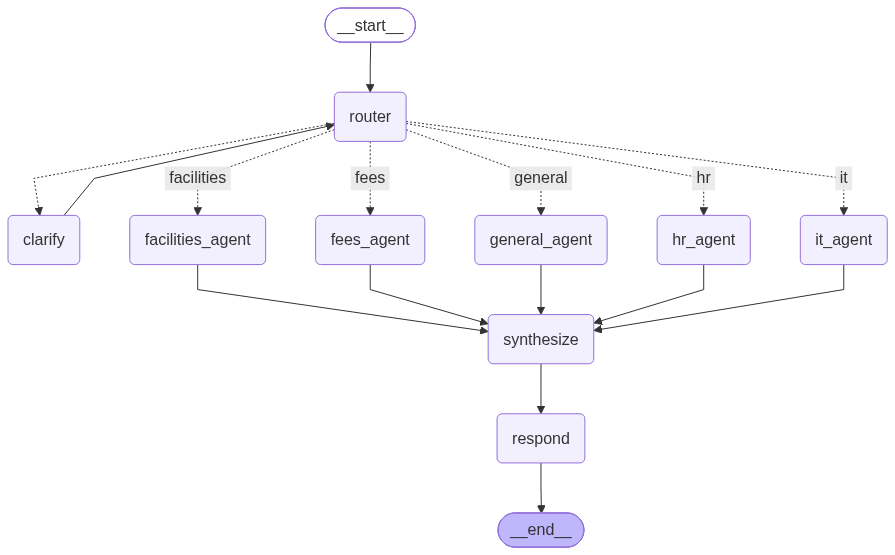

In [7]:
agent

In [28]:
chat_history = ""
user_query = "my wifi is not working"

In [17]:
messages = [
    SystemMessage(content=system_prompt),
    HumanMessage(
        content=f"""
Conversation history:
{chat_history}

User query:
{user_query}
"""
    )
]

In [29]:
initial_state = {
    "current_query": user_query,
}


In [30]:
config = {
    "configurable": {
        "thread_id": "student-demo-1",
    }
}
result = agent.invoke(initial_state, config=config)


In [31]:
print(result)

{'messages': [{'role': 'user', 'content': 'my wifi is not working'}, {'role': 'assistant', 'content': '{\n  "answer": "1. Ensure the Wi‑Fi adapter is turned on.\\n2. Verify the device’s date and time are correct.\\n3. Connect to the correct SSID (e.g., NBU‑Student) and confirm your university credentials are up‑to‑date.\\n4. If the connection still fails, forget the network and reconnect to clear stale authentication data.\\n5. If multiple devices in the same room cannot connect while devices elsewhere work, note the building, floor, room, and affected device and report this to Network Operations so they can inspect the access point.\\n6. Remember that personal wireless routers or unauthorized extenders are not allowed in residence rooms, as they can cause address conflicts.\\nIf the issue persists after these steps, contact the university IT help desk for further assistance."\n}'}], 'current_query': 'my wifi is not working', 'detected_domains': ['IT'], 'intent': 'IT', 'routing_confide

In [21]:
result["final_answer"]

'{\n  "answer": "1. Make sure Wi‑Fi is turned on on your device.\\n2. Verify the device’s date and time are correct.\\n3. Connect to the correct university SSID (e.g.,\u202fNBU‑Student for students).\\n4. Confirm your university credentials are up‑to‑date.\\n5. If it still won’t connect, forget the network and reconnect.\\n6. If several devices in the same room are affected while others work, report the building, floor, room and the affected device(s) to Network Operations for AP inspection.\\n7. Remember that personal wireless routers or extenders are not allowed in residence halls and can cause interference.",\n  "needHumanHelp": false,\n  "uncertainty": null\n}'

In [22]:
result["detected_domains"]

['IT']

In [15]:
from knowledge_retrieval import (
    FACILITIES_KNOWLEDGE_BASE,
    FINANCE_KNOWLEDGE_BASE,
    HR_KNOWLEDGE_BASE,
    IT_KNOWLEDGE_BASE,
    retrieve_documents,
)

collection_by_department = {
    "IT": IT_KNOWLEDGE_BASE,
    "HR": HR_KNOWLEDGE_BASE,
    "Fees": FINANCE_KNOWLEDGE_BASE,
    "Facilities": FACILITIES_KNOWLEDGE_BASE,
}

department = result.get("detected_domains", [None])[0]
collection_name = collection_by_department.get(department)

if collection_name is None:
    print(f"No PDF retrieval is used for department: {department or 'Unknown'}")
else:
    retrieved_documents = retrieve_documents(
        query=user_query,
        collection_name=collection_name,
        number_of_documents=4,
    )

    print(f"Retrieved {len(retrieved_documents)} documents from {collection_name}:\n")
    for index, document in enumerate(retrieved_documents, start=1):
        source = document.metadata.get("source", "Unknown document")
        page = document.metadata.get("page")
        page_label = f", page {page + 1}" if isinstance(page, int) else ""
        print(f"--- Document {index}: {source}{page_label} ---")
        print(document.page_content)
        print()

No PDF retrieval is used for department: General


In [32]:
user_query = "what should I do next?"
initial_state = {"current_query": user_query}
result = agent.invoke(initial_state, config=config)
print("messages retained:", len(result["messages"]))
print(result["final_answer"])


messages retained: 4
{
  "answer": "Report the building, floor, room, and affected device to the Service Desk (Network Operations) so they can investigate the Wi‑Fi problem.",
  "steps": [
    "Identify the building, floor, room, and the specific Wi‑Fi device that is experiencing issues.",
    "Contact the Service Desk (Network Operations) via the appropriate channel (phone, email, or ticketing system).",
    "Provide the building, floor, room, and device details in your report.",
    "Await further instructions or resolution from the Service Desk."
  ],
  "uncertainty": null,
  "needHumanAssistance": true
}
